**Registration Number: 23/EG/CO/027**

Unsupervised And Semi-Supervised Learning Detection in Engineering Sensor Data


In [1]:
# Import project Dependencies
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, confusion_matrix, silhouette_score)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
SAMPLE_SIZE = 58000

In [2]:
# Read the dataset
file_path = "../Datasets/shuttle.csv"
data = pd.read_csv(file_path)
data

,Rad Flow,Fpv Close,Fpv Open,High,Bypass,Bpv Close,Bpv Open,Class
0,77,0,28,0,27,48,22,2
1,92,0,0,26,36,92,56,4
2,82,0,52,-5,29,30,2,1
3,76,0,28,18,40,48,8,1
4,79,0,34,-26,43,46,2,1
...,...,...,...,...,...,...,...,...
57995,84,0,-36,-29,4,120,116,5
57996,81,0,-20,25,26,102,76,4
57997,77,0,12,-22,22,65,42,4
57998,103,0,18,-16,66,85,20,1


In [3]:
from sklearn.datasets import fetch_openml

try:
    shuttle = pd.read_csv(file_path)
    X = shuttle.drop(columns=['Class']).copy()
    shuttle_class = shuttle['Class'].astype(int).to_numpy()
except Exception:
    shuttle = fetch_openml('shuttle', version=1, as_frame=True)
    X = shuttle.data.copy()
    shuttle_class = shuttle.target.astype(int).to_numpy()


In [4]:
data = X.copy()
data['Class'] = np.asarray(shuttle_class).astype(int)
print("Dataset shape:", data.shape)
print("Sensor columns:", list(X.columns))


Dataset shape: (58000, 8)
Sensor columns: ['Rad Flow', 'Fpv Close', 'Fpv Open', 'High', 'Bypass', 'Bpv Close', 'Bpv Open']


In [5]:
# Class classificaition and anomaly detection
print("\nClass counts (1 = normal flight state):")
print(data['Class'].value_counts().sort_index())

data['anomaly'] = (data['Class'] != 1).astype(int)
print("\nNormal vs Anomaly:")
print(data['anomaly'].value_counts())


Class counts (1 = normal flight state):
Class
1    45586
2       50
3      171
4     8903
5     3267
6       10
7       13
Name: count, dtype: int64

Normal vs Anomaly:
anomaly
0    45586
1    12414
Name: count, dtype: int64


In [6]:
# Conduct safety checks
feature_names = list(X.columns)
print(feature_names)

['Rad Flow', 'Fpv Close', 'Fpv Open', 'High', 'Bypass', 'Bpv Close', 'Bpv Open']


In [7]:
# Replace and drop infinite values
data = data.replace([np.inf, -np.inf], np.nan)
print("Missing/infinite cells:", int(data.isnull().sum().sum()))

data = data.dropna()
data.info()


Missing/infinite cells: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58000 entries, 0 to 57999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Rad Flow   58000 non-null  int64
 1   Fpv Close  58000 non-null  int64
 2   Fpv Open   58000 non-null  int64
 3   High       58000 non-null  int64
 4   Bypass     58000 non-null  int64
 5   Bpv Close  58000 non-null  int64
 6   Bpv Open   58000 non-null  int64
 7   Class      58000 non-null  int64
 8   anomaly    58000 non-null  int64
dtypes: int64(9)
memory usage: 4.0 MB


In [8]:
# Remove Duplicate rows
rows_before = data.shape[0]
data = data.drop_duplicates()
print("Duplicate rows removed:", rows_before - data.shape[0])
print("Clean shape:", data.shape)

Duplicate rows removed: 16354
Clean shape: (41646, 9)


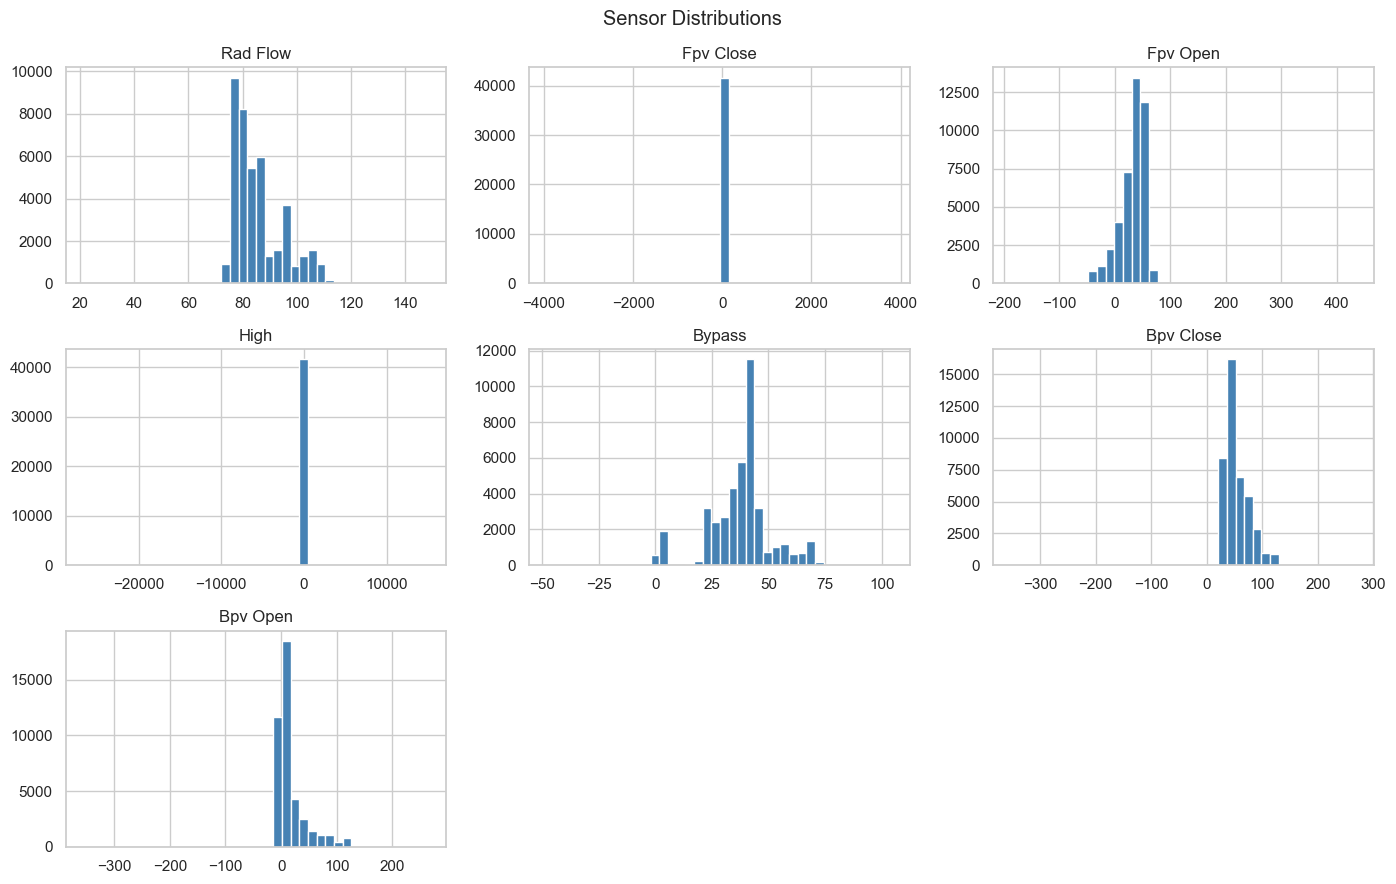

In [9]:
# Histogram distribution showing the spread of the dataset
data[feature_names].hist(figsize=(14, 9), bins=40, color='steelblue',
edgecolor='white')
plt.suptitle("Sensor Distributions")
plt.tight_layout()
plt.show()


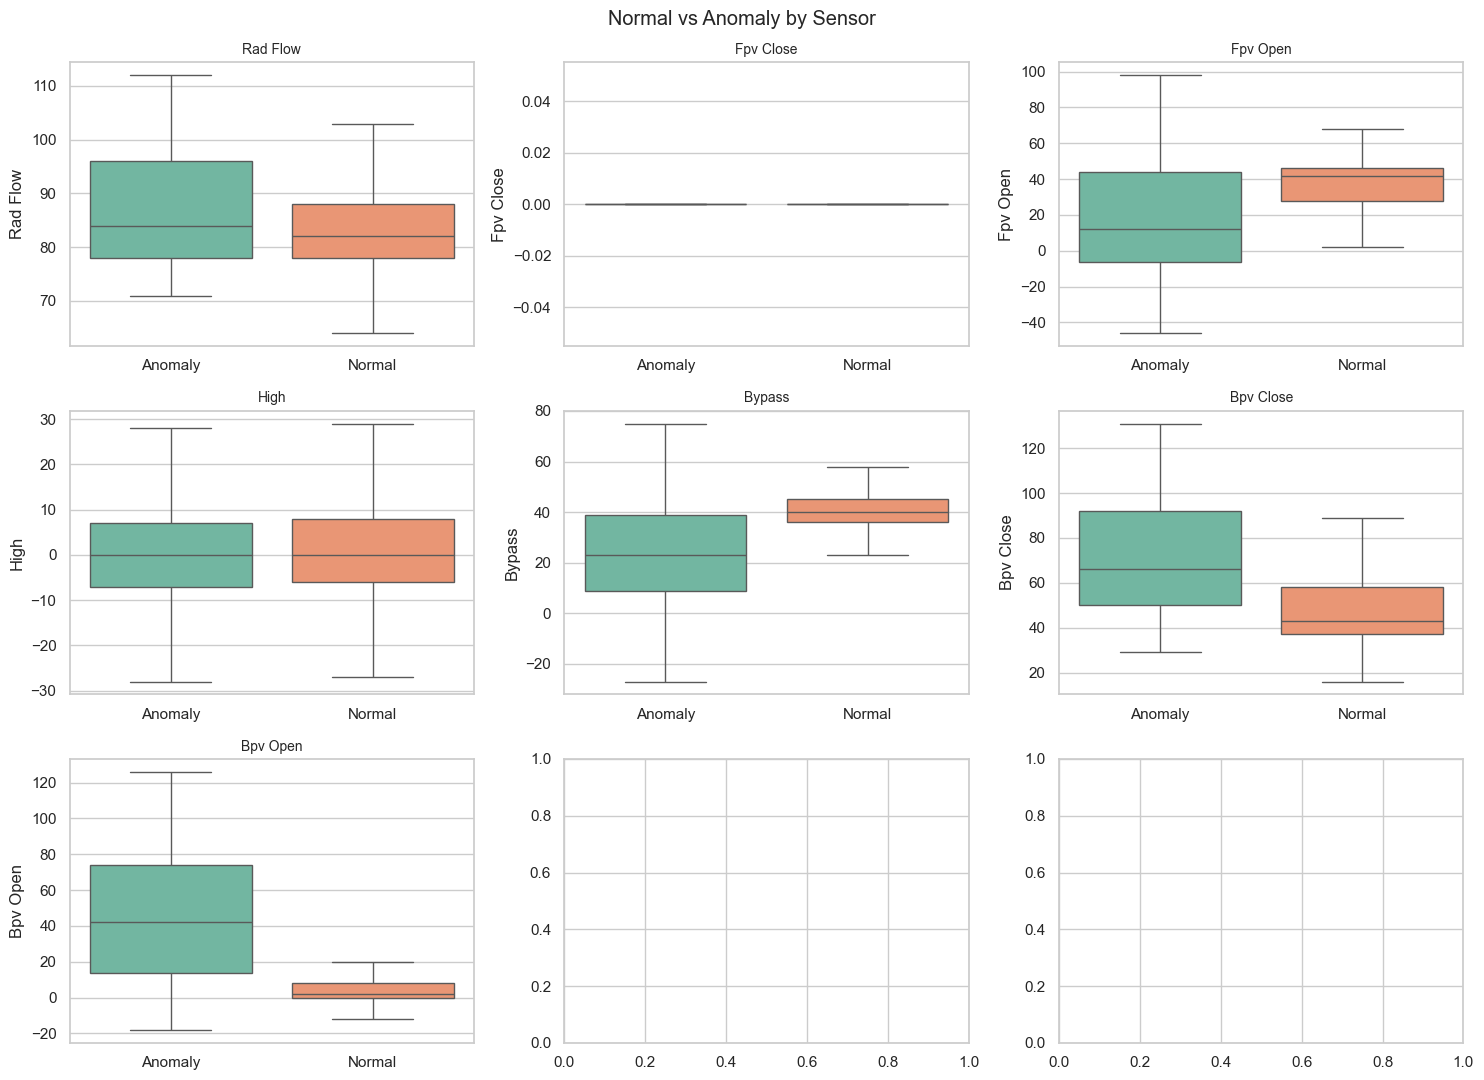

In [10]:
# Compare anaomaly and normal distribution of each of the sensors
label_text = data['anomaly'].map({0: 'Normal', 1: 'Anomaly'})
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), feature_names):
    sns.boxplot(x=label_text, y=data[col], hue=label_text, palette='Set2',
    ax=ax, legend=False, showfliers=False)
    ax.set_title(col, fontsize=10); ax.set_xlabel("")
plt.suptitle("Normal vs Anomaly by Sensor")
plt.tight_layout()
plt.show()


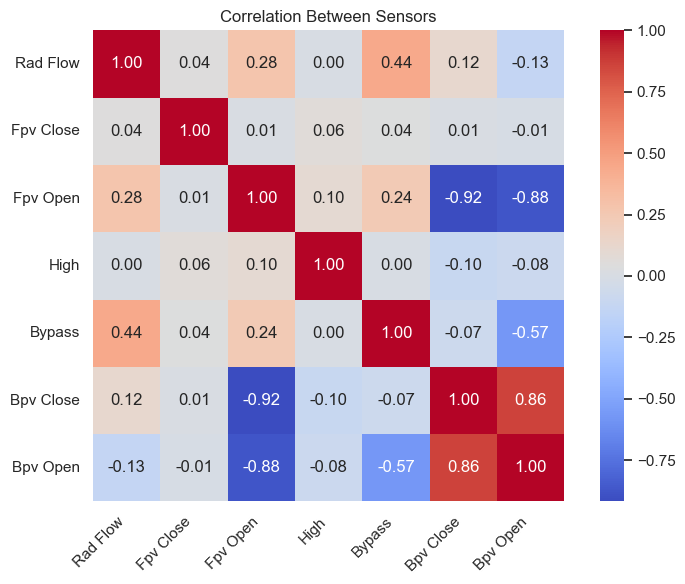

In [11]:
# Correlation Heatmap to show which of the sensors carry similar information
plt.figure(figsize=(8, 6))
sns.heatmap(data[feature_names].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Between Sensors")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
# Score each sensor and label them to be Normal or Anomaly
normal_rows = data[data['anomaly'] == 0]
anomaly_rows = data[data['anomaly'] == 1]
separation = {}
for f in feature_names:
    std = data[f].std()
    if std > 0:
        separation[f] = abs(anomaly_rows[f].mean() - normal_rows[f].mean()) / std
    else:
        separation[f] = 0
        
ranking = sorted(separation, key=separation.get, reverse=True)
print("Sensors ranked by how well they separate Normal vs Anomaly:")
for f in ranking:
    print(f" {f:<18} score = {separation[f]:.3f}")

Sensors ranked by how well they separate Normal vs Anomaly:
 Bpv Open           score = 1.550
 Bypass             score = 1.327
 Bpv Close          score = 1.065
 Fpv Open           score = 0.930
 Rad Flow           score = 0.224
 High               score = 0.016
 Fpv Close          score = 0.008


In [13]:
# Build all X Sensors
X_full = data[feature_names].copy()
y_full = data['anomaly'].astype(int)
if len(X_full) > SAMPLE_SIZE:
    X_full, _, y_full, _ = train_test_split(X_full, y_full, train_size=SAMPLE_SIZE,
            random_state=RANDOM_STATE, stratify=y_full)


In [14]:
# Split into test and train test set.
x_train, x_test, y_train, y_test = train_test_split(
X_full,y_full, test_size=0.3, random_state=RANDOM_STATE, stratify=y_full)

In [15]:
# Scale Training Features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(x_train)
X_test_sc = scaler.transform(x_test)
contamination = float(y_train.mean())
print(f"\nTraining rows: {len(x_train)}, Test rows: {len(x_test)}")
print(f"Share of anomalies in training data: {contamination:.3f}")



Training rows: 29152, Test rows: 12494
Share of anomalies in training data: 0.243


In [16]:
# Define helpers to use in every method
# Detectors output +1 (normal) / -1 (anomaly). Turn that into 1 = anomaly, 0.
def to_anomaly(prediction):
    return (np.asarray(prediction) == -1).astype(int)

results = []
test_predictions = {}

def evaluate(name, y_pred):
    y_pred = np.asarray(y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    print(f"\n {name}")
    print(f"Accuracy : {accuracy:.2%}")
    print(f"Precision: {precision:.2%} (of the alerts, how many were real anomalies)")
    print(f"Recall : {recall:.2%} (of the real anomalies, how many we caught)")
    print(f"F1-Score : {f1:.2%}")
    print(f"Confusion: TN={tn} FP(false alarms)={fp} FN(missedanomalies)={fn} TP={tp}")
    
    results.append({"Method": name, "Accuracy": accuracy, "Precision":
    precision, "Recall": recall, "F1-Score": f1, "False Alarms (FP)": fp,
    "Missed Anomalies (FN)": fn})
    test_predictions[name] = y_pred


    # Visualize the confusion matrix using a heatmap
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5, 4), dpi=100)
    labels = ['Normal', 'Anomaly']
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 14})
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

In [17]:
# check how seperated the clusters are
silhouette_scores = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=10,
    random_state=RANDOM_STATE).fit_predict(X_train_sc)
    
    S = silhouette_score(X_train_sc, labels, sample_size=5000,
    random_state=RANDOM_STATE)
silhouette_scores.append(S)
print(f"k={k:<2} silhouette score={S:.4f}")

k=8  silhouette score=0.4367


k=2  silhouette score=0.5248
k=3  silhouette score=0.4363
k=4  silhouette score=0.4423
k=5  silhouette score=0.4439
k=6  silhouette score=0.4411
k=7  silhouette score=0.4245
k=8  silhouette score=0.4367


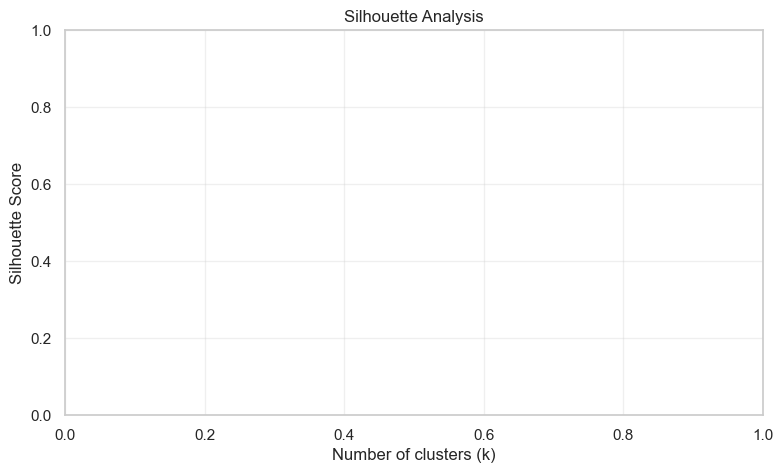

In [23]:
# visualize thes sillhouete scores
plt.figure(figsize=(9, 5))
# check how seperated the clusters are
silhouette_scores = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, n_init=10,
                    random_state=RANDOM_STATE).fit_predict(X_train_sc)
    S = silhouette_score(X_train_sc, labels, sample_size=5000,
                         random_state=RANDOM_STATE)
    silhouette_scores.append(S)
    print(f"k={k:<2} silhouette score={S:.4f}")
plt.xlabel("Number of clusters (k)");
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(alpha=0.3)
plt.savefig("../Output/results/lab5_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()


In [24]:
# Train the K-Means Model
kmeans = KMeans(n_clusters=2, n_init=10,
random_state=RANDOM_STATE).fit(X_train_sc)


In [25]:
# K-Means clusters
cluster_to_label = {}
for cluster_id in [0, 1]:
    anomaly_pct = y_train.values[kmeans.labels_ == cluster_id].mean()
    cluster_to_label[cluster_id] = int(anomaly_pct > 0.5)
    print(f"Cluster {cluster_id}: {anomaly_pct:.0%} anomaly -> "
    f"{'Anomaly' if anomaly_pct > 0.5 else 'Normal'}")

Cluster 0: 80% anomaly -> Anomaly
Cluster 1: 13% anomaly -> Normal



 K-Means
Accuracy : 85.55%
Precision: 80.46% (of the alerts, how many were real anomalies)
Recall : 53.48% (of the real anomalies, how many we caught)
F1-Score : 64.25%
Confusion: TN=9067 FP(false alarms)=394 FN(missedanomalies)=1411 TP=1622


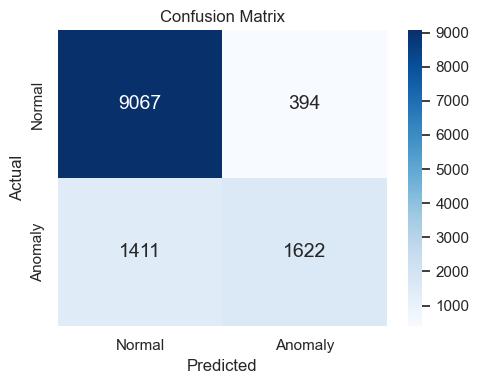

In [26]:
# Predict the testset
test_clusters = kmeans.predict(X_test_sc)
km_pred = [cluster_to_label[c] for c in test_clusters]
evaluate("K-Means", km_pred)

In [27]:
# Detect noise
print("Trying different DBSCAN settings (looking for the best F1):")
best_f1 = -1
for eps in [0.5, 1.0, 2.0, 3.0]:
    for min_samples in [5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_test_sc)
        pred = (labels == -1).astype(int)
        f1 = f1_score(y_test, pred, zero_division=0)
        print(
            f"eps={eps}, min_samples={min_samples} "
            f"-> flagged={pred.sum()}, F1={f1:.3f}"
             )
if f1 > best_f1:
    best_f1 = f1
    best_eps = eps
    best_ms = min_samples

Trying different DBSCAN settings (looking for the best F1):
eps=0.5, min_samples=5 -> flagged=82, F1=0.026
eps=0.5, min_samples=10 -> flagged=95, F1=0.034
eps=1.0, min_samples=5 -> flagged=45, F1=0.014
eps=1.0, min_samples=10 -> flagged=52, F1=0.018
eps=2.0, min_samples=5 -> flagged=29, F1=0.009
eps=2.0, min_samples=10 -> flagged=34, F1=0.012
eps=3.0, min_samples=5 -> flagged=24, F1=0.009
eps=3.0, min_samples=10 -> flagged=24, F1=0.009



 DBSCAN (eps=3.0, min_samples=10)
Accuracy : 75.74%
Precision: 54.17% (of the alerts, how many were real anomalies)
Recall : 0.43% (of the real anomalies, how many we caught)
F1-Score : 0.85%
Confusion: TN=9450 FP(false alarms)=11 FN(missedanomalies)=3020 TP=13


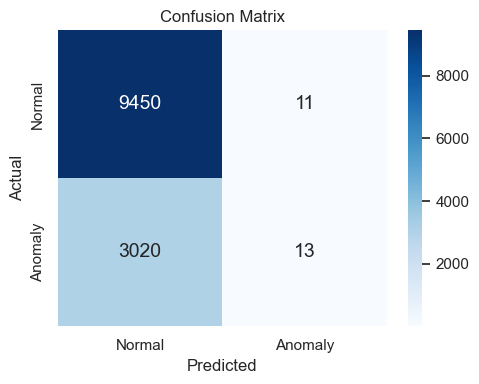

In [28]:
# USE the best setting to evaluate
dbscan = DBSCAN(eps=best_eps, min_samples=best_ms)
db_labels = dbscan.fit_predict(X_test_sc)
db_pred = (db_labels == -1).astype(int)
evaluate(f"DBSCAN (eps={best_eps}, min_samples={best_ms})", db_pred)



 Isolation Forest
Accuracy : 76.25%
Precision: 51.09% (of the alerts, how many were real anomalies)
Recall : 50.81% (of the real anomalies, how many we caught)
F1-Score : 50.95%
Confusion: TN=7986 FP(false alarms)=1475 FN(missedanomalies)=1492 TP=1541


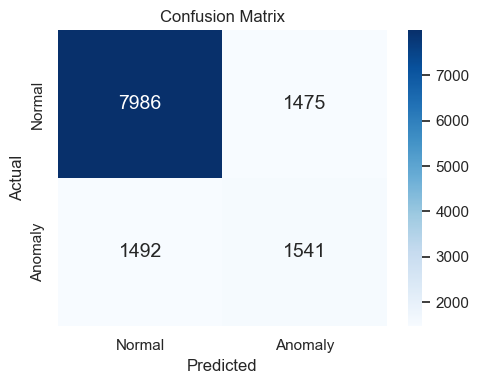

In [30]:
# Isolate Forest Implementation
iso_forest = IsolationForest(contamination=contamination,
random_state=RANDOM_STATE)
iso_forest.fit(X_train_sc) 
evaluate("Isolation Forest", to_anomaly(iso_forest.predict(X_test_sc)))


 LOF
Accuracy : 63.60%
Precision: 26.45% (of the alerts, how many were real anomalies)
Recall : 28.06% (of the real anomalies, how many we caught)
F1-Score : 27.23%
Confusion: TN=7095 FP(false alarms)=2366 FN(missedanomalies)=2182 TP=851


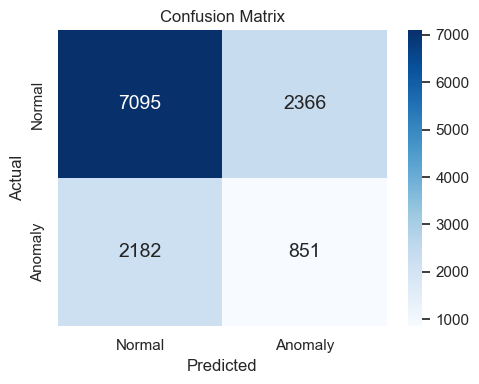

In [31]:
# Implement Local outlier
lof = LocalOutlierFactor(n_neighbors=20, novelty=True,
contamination=contamination)
lof.fit(X_train_sc)
evaluate("LOF", to_anomaly(lof.predict(X_test_sc)))


 One-Class SVM
Accuracy : 85.49%
Precision: 70.07% (of the alerts, how many were real anomalies)
Recall : 70.23% (of the real anomalies, how many we caught)
F1-Score : 70.15%
Confusion: TN=8551 FP(false alarms)=910 FN(missedanomalies)=903 TP=2130


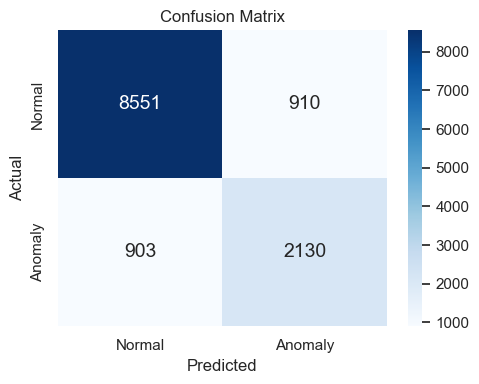

In [32]:
# One class svm
normal_only = X_train_sc[y_train.values == 0]
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
oc_svm.fit(normal_only)
evaluate("One-Class SVM", to_anomaly(oc_svm.predict(X_test_sc)))


In [33]:
# Display each method side by side
comparison = pd.DataFrame(results)
print("COMPARISON OF ALL METHODS (Anomaly = the rare state we want to catch)")
print(comparison.round(4).to_string(index=False))

best_f1 = comparison.loc[comparison['F1-Score'].idxmax(), 'Method']
best_recall = comparison.loc[comparison['Recall'].idxmax(), 'Method']
fewest_fp = comparison.loc[comparison['False Alarms (FP)'].idxmin(),
'Method']
fewest_fn = comparison.loc[comparison['Missed Anomalies (FN)'].idxmin(),
'Method']

print("Best F1-Score :", best_f1)
print("Caught most anomalies :", best_recall)
print("Fewest false alarms :", fewest_fp)
print("Fewest missed anomalies:", fewest_fn)

COMPARISON OF ALL METHODS (Anomaly = the rare state we want to catch)
                          Method  Accuracy  Precision  Recall  F1-Score  False Alarms (FP)  Missed Anomalies (FN)
                         K-Means    0.8555     0.8046  0.5348    0.6425                394                   1411
DBSCAN (eps=3.0, min_samples=10)    0.7574     0.5417  0.0043    0.0085                 11                   3020
                Isolation Forest    0.7625     0.5109  0.5081    0.5095               1475                   1492
                             LOF    0.6360     0.2645  0.2806    0.2723               2366                   2182
                   One-Class SVM    0.8549     0.7007  0.7023    0.7015                910                    903
Best F1-Score : One-Class SVM
Caught most anomalies : One-Class SVM
Fewest false alarms : DBSCAN (eps=3.0, min_samples=10)
Fewest missed anomalies: One-Class SVM
